# <center> Emotions Classification in Images <center/>
<center> <b>DLBDSAIS02<b/> - Project : Artificial Intelligence <center/>
<center> IU International University of Applied Sciences <center/>

## Objective :
In this project, our goal is to develop a model capable of classifying facial expressions into one of **five emotion categories**: Anger, Joy, Neutral, Sad, and Surprise. Emotion recognition from facial images is a fundamental task in affective computing with applications in human-computer interaction, mental health monitoring, and customer experience analysis.

In this notebook, we walk through the complete pipeline  from exploratory data analysis to model training and evaluation  to select the best-performing architecture for this task.

## Table of Contents
1. [Exploratory Data Analysis](#1-exploratory-data-analysis)
    * 1.1. [Class Distribution](#11-class-distribution)
    * 1.2. [Sample Images](#12-sample-images)
    * 1.3. [Image Properties](#13-image-properties)
    * 1.4. [Pixel Intensity Analysis](#14-pixel-intensity-analysis)
    * 1.5. [Per-Channel Statistics](#15-per-channel-statistics)
2. [Data Preparation](#2-data-preparation)
    * 2.1. [Transforms & Augmentation](#21-transforms--augmentation)
    * 2.2. [Datasets & DataLoaders](#22-datasets--dataloaders)
    * 2.3. [Class Weight Computation](#23-class-weight-computation)
    * 2.4. [Augmentation Preview](#24-augmentation-preview)
3. [Model Development](#3-model-development)
    * 3.1. [Baseline CNN](#31-baseline-custom-cnn)
    * 3.2. [ResNet-18 (Transfer Learning)](#32-transfer-learning-resnet-18)
    * 3.3. [Training Infrastructure](#33-training-infrastructure)
    * 3.4. [Training](#34-training)
4. [Evaluation & Analysis](#4-evaluation--analysis)
    * 4.1. [Training Curves](#41-training-curves)
    * 4.2. [Test Set Evaluation](#42-test-set-evaluation)
    * 4.3. [Confusion Matrices](#43-confusion-matrices)
    * 4.4. [Model Comparison](#44-model-comparison)
    * 4.5. [Misclassified Samples](#45-misclassified-samples)
5. [Summary](#5-summary)


## About the Dataset
The dataset used in this project is **AffectNet** (Facial Expression Dataset), available on [Kaggle](https://www.kaggle.com/datasets/mstjebashazida/affectnet).

### Key Dataset Characteristics:
- **Target Emotion Classes**: Filtered to **four primary categories**: **Anger**, **Happy (Joy)**, **Neutral**, and **Surprise**.
- **Image Resolution**: Native **96×96 pixels** in **RGB** color mode (JPEG/PNG format).
- **Folder Structure**: Structured into `Train/` and `Test/` subdirectories with folder names corresponding to emotion classes.
- **Validation Split**: An **80/20 stratified train/validation split** is dynamically constructed from `Train/` to ensure unbiased validation.



To download the AffectNet dataset directly from Kaggle using `kagglehub`, use the following snippet:

In [1]:
# Uncomment in case you want to download the AffectNet dataset via kagglehub
import kagglehub
path_to_data = kagglehub.dataset_download("mstjebashazida/affectnet")
print("Path to dataset files:", path_to_data)

Using Colab cache for faster access to the 'affectnet' dataset.
Path to dataset files: /kaggle/input/affectnet


We begin by importing all necessary libraries and setting up global configuration variables.

In [2]:
# Import the required libraries
from sklearn.metrics import classification_report, f1_score, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import matplotlib.pyplot as plt
from collections import Counter
import torch.optim as optim
from pathlib import Path
import seaborn as sns
import torch.nn as nn
from PIL import Image
import pandas as pd
import numpy as np
import warnings
import random
import torch
import os

#### Start by setting the universal variables.

Note that data paths depend on your setup: running locally (CPU) versus using Google Colab for heavier computation

In [3]:
# We change this depending on the setup
local_machine = False

# Paths (relative to notebooks/ directory)
MODEL_DIR = Path('../models')
MODEL_DIR.mkdir(exist_ok=True)
ASSETS_DIR = Path('../assets')
ASSETS_DIR.mkdir(exist_ok=True)
if local_machine:
    # Specify local data folder
    DATA_DIR = Path('../data')
    TRAIN_DIR = DATA_DIR / 'Train'
    TEST_DIR  = DATA_DIR / 'Test'

else :
    # Specify colab server path
    DATA_DIR = Path(f'{path_to_data}/archive (3)')
    TRAIN_DIR = DATA_DIR / 'Train'
    TEST_DIR  = DATA_DIR / 'Test'

Define target classes and counts, set hyperparameters, and apply ImageNet normalization

In [4]:
# Class names match AffectNet folder names (lowercase)
CLASS_NAMES = ['anger', 'happy', 'neutral', 'sad', 'surprise']
NUM_CLASSES = len(CLASS_NAMES)

# Image & training hyperparameters
IMG_SIZE        = 224      # Both models use 224x224
BATCH_SIZE      = 32       # Smaller batch for 224x224 images
LEARNING_RATE   = 1e-3
NUM_EPOCHS      = 20
PATIENCE        = 4

# ImageNet normalization (standard for pretrained models)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

Handle warnings, visual styling, reproducibility (random seeds), and device selection

In [5]:
# Ignore low warnings
warnings.filterwarnings('ignore')

# Visual style
sns.set_style('whitegrid')
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.figsize'] = (12, 6)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

# Device selection
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU Name     : {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device : cuda
GPU Name     : Tesla T4
GPU Memory   : 15.6 GB


## <a id="1-exploratory-data-analysis">1. Exploratory Data Analysis</a>


### <a id="11-class-distribution">1.1 Class Distribution</a>
Let's start by analyzing the distribution of images in each emotion class across the training and test splits.


In [6]:
def count_images(directory) -> dict:
    """
    Count images per target class in a directory (case-insensitive matching).
    :param directory: Path to the directory containing the images.
    :return: Dictionary mapping class names to the number of images in that class.
    """
    # Initialize an empty dictionary
    counts_dict = {}

    # Get the target classes
    target = {c.lower() for c in CLASS_NAMES}

    # Check if the directory exists and contains images
    for cls_dir in sorted(directory.iterdir()):
        if cls_dir.is_dir() and cls_dir.name.lower() in target:
            counts_dict[cls_dir.name.lower()] = len(list(cls_dir.glob('*')))

    # Return the counts
    return counts_dict

In [7]:
# Count images per split
train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)

# Build summary DataFrame
df_counts = pd.DataFrame({
    'Train': train_counts,
    'Test': test_counts
}).fillna(0).astype(int)

df_counts.loc['TOTAL'] = df_counts.sum()

# Display DataFrame
df_counts

,Train,Test
anger,1500,1718
happy,2340,2704
neutral,2758,2368
sad,3091,1584
surprise,2119,1920
TOTAL,11808,10294


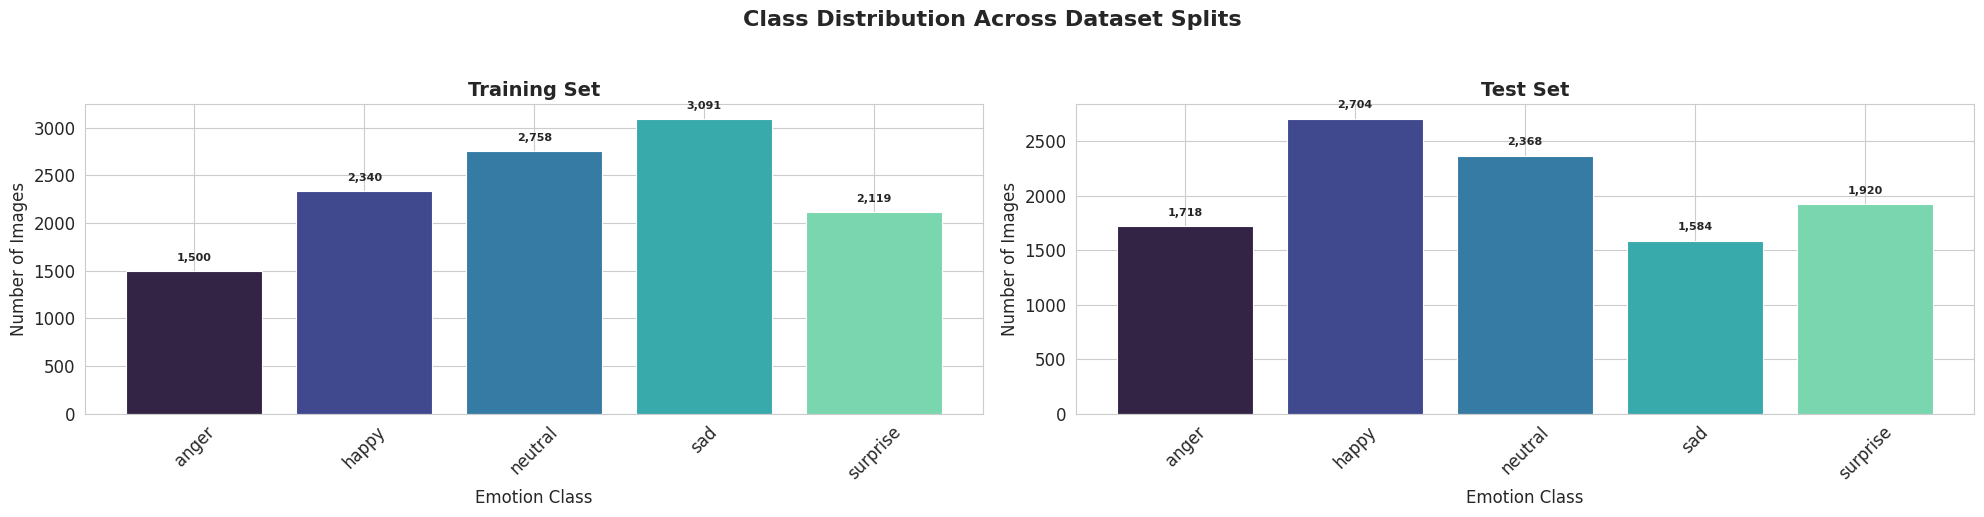

In [8]:
# Initiate a figure
fig, axes = plt.subplots(1, 2, figsize=(20, 5))
palette = sns.color_palette('mako', NUM_CLASSES)

# Define splits
splits = {
    'Training Set': train_counts,
    'Test Set': test_counts
}

# Loop on the splits
for ax, (title, counts) in zip(axes, splits.items()):

    # Create barchart
    bars = ax.bar(counts.keys(), counts.values(), color=palette, edgecolor='white', linewidth=0.8)

    # Set plot properties
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Emotion Class')
    ax.set_ylabel('Number of Images')
    ax.tick_params(axis='x', rotation=45)

    # Annotate bars
    for bar, count in zip(bars, counts.values()):
        ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 80,
                f'{count:,}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Add subtitle, adjust view, and display it
plt.suptitle('Class Distribution Across Dataset Splits', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

In [9]:
# Imbalance summary
max_cls = max(train_counts, key=train_counts.get)
min_cls = min(train_counts, key=train_counts.get)
ratio   = train_counts[max_cls] / train_counts[min_cls]

print('Class Imbalance Analysis (Training Set)')
print('=' * 45)
print(f'  Largest class  : {max_cls:>8s} = {train_counts[max_cls]:>6,} images')
print(f'  Smallest class : {min_cls:>8s} = {train_counts[min_cls]:>6,} images')
print(f'  Imbalance ratio: {ratio:.1f}x')
print('=' * 45)

Class Imbalance Analysis (Training Set)
  Largest class  :      sad =  3,091 images
  Smallest class :    anger =  1,500 images
  Imbalance ratio: 2.1x


### <a id="12-sample-images">1.2 Sample Images</a>
Let me visualize random sample images from each target emotion class to build visual intuition about the dataset.


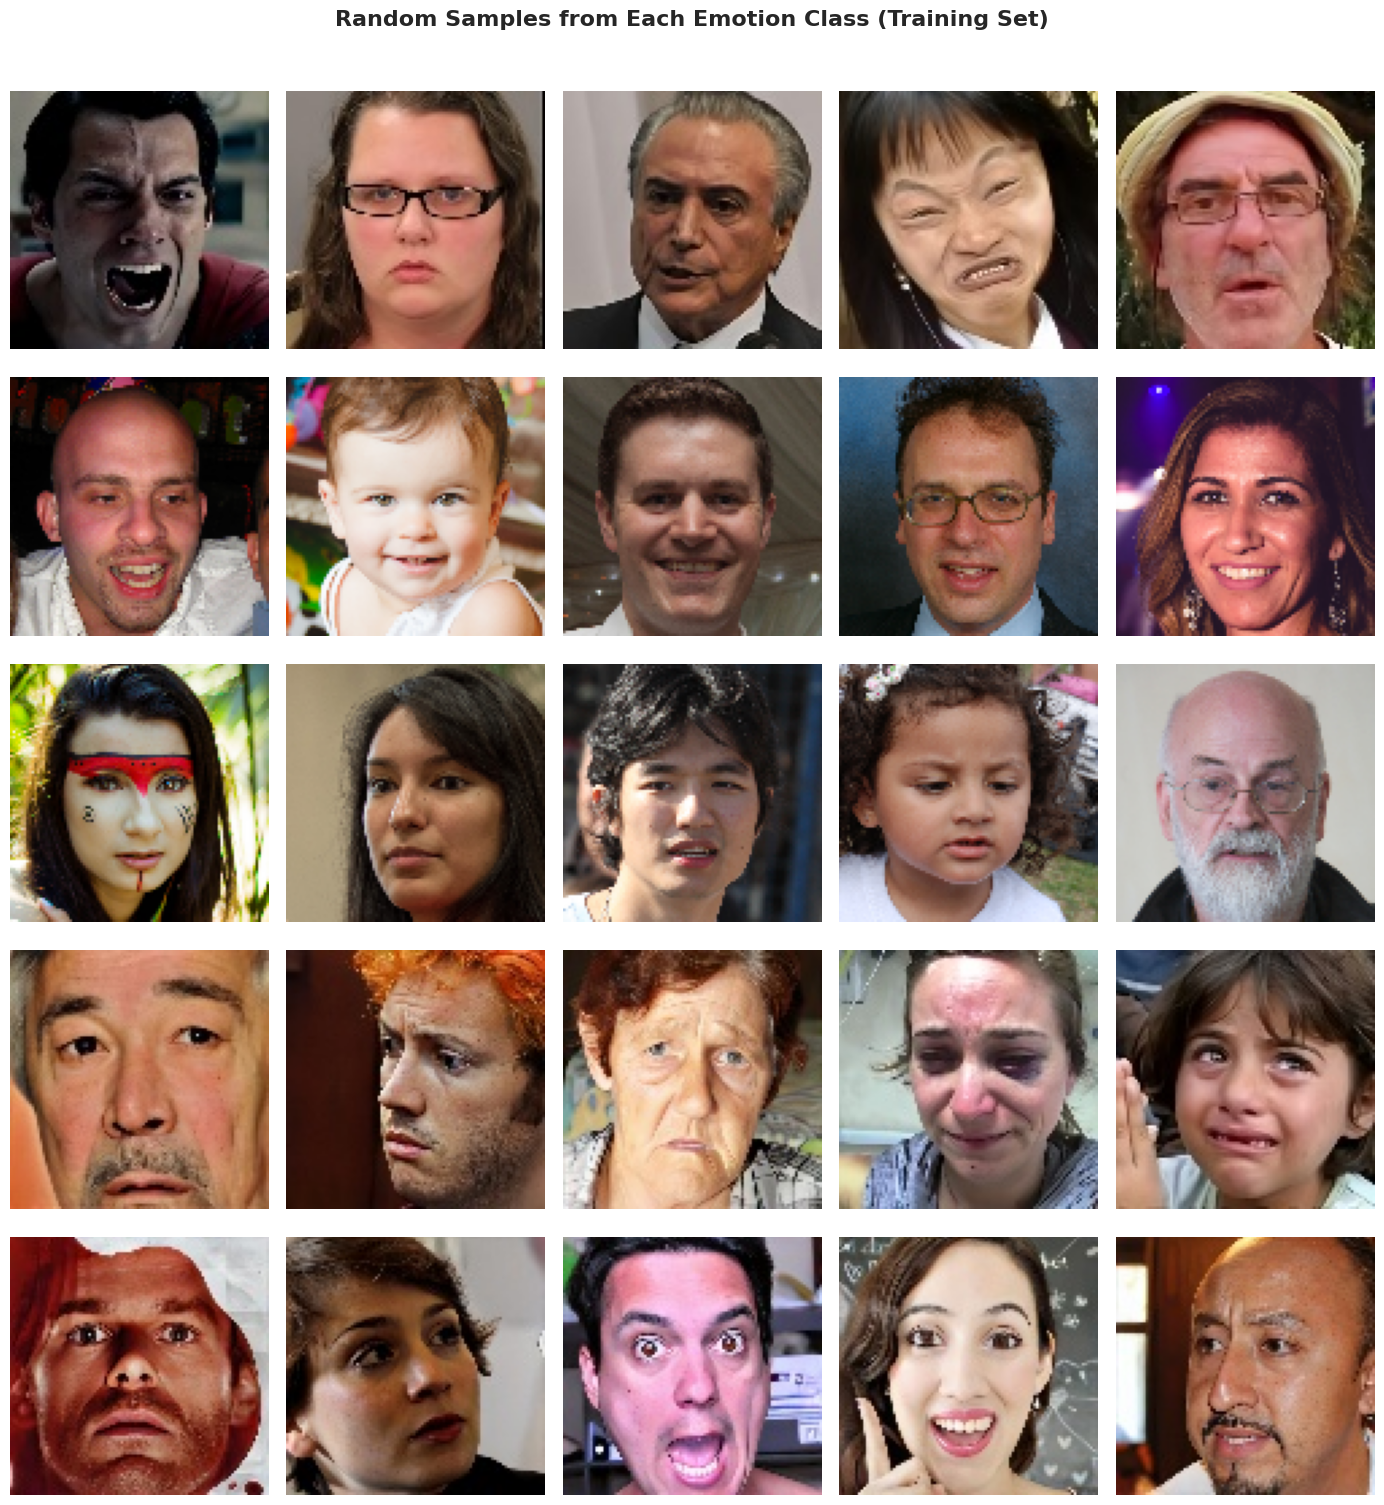

In [11]:
# Display a grid of sample images: 7 rows (classes) × 5 columns (samples)
fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(14, 3 * NUM_CLASSES))

for i, cls_name in enumerate(CLASS_NAMES):
    cls_dir = TRAIN_DIR / cls_name
    sample_files = random.sample(list(cls_dir.iterdir()), 5)

    for j, img_path in enumerate(sample_files):
        img = Image.open(img_path)
        axes[i, j].imshow(img)
        axes[i, j].axis('off')

        if j == 0:
            axes[i, j].set_ylabel(cls_name.upper(), fontsize=12, fontweight='bold', rotation=0, labelpad=60, va='center')
            axes[i, j].yaxis.set_visible(True)
            axes[i, j].tick_params(left=False)

# Add title
plt.suptitle('Random Samples from Each Emotion Class (Training Set)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()

# Save the image (only locally)
plt.savefig('/assets/Fig 1. - Sample images from the dataset.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

### <a id="13-image-properties">1.3 Image Properties</a>
We verify that all images are consistent in terms of size and color mode.


In [ ]:
# Sample images from all target classes to check properties
sample_info = {'size': [], 'mode': [], 'class': []}

target_set = {c.lower() for c in CLASS_NAMES}
for cls_dir in sorted(TRAIN_DIR.iterdir()):
    if cls_dir.is_dir() and cls_dir.name.lower() in target_set:
        for img_path in list(cls_dir.iterdir())[:10]:
            img = Image.open(img_path)
            sample_info['size'].append(img.size)
            sample_info['mode'].append(img.mode)
            sample_info['class'].append(cls_dir.name)

df_props = pd.DataFrame(sample_info)

print('Image Properties Summary (AffectNet)')
print('=' * 45)
print(f"  Unique sizes : {df_props['size'].unique()}")
print(f"  Unique modes : {df_props['mode'].unique()}")
print(f"  All uniform  : {df_props['size'].nunique() == 1 and df_props['mode'].nunique() == 1}")
print(f"  Image shape  : {df_props['size'].iloc[0][0]}x{df_props['size'].iloc[0][1]} pixels")
print(f"  Color space  : {df_props['mode'].iloc[0]}")

### <a id="14-pixel-intensity-analysis">1.4 Pixel Intensity Analysis</a>
By examining the distribution of mean pixel intensities per class, we can see if certain emotions are systematically brighter or darker.


In [ ]:
# Configure the basics of the plot
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes = axes.flatten()
palette = sns.color_palette('mako', NUM_CLASSES)

# Compute mean pixel intensity for each class
for i, cls_name in enumerate(CLASS_NAMES):
    cls_dir = TRAIN_DIR / cls_name
    sample_files = random.sample(list(cls_dir.iterdir()),
                                  min(200, len(list(cls_dir.iterdir()))))

    # Compute mean pixel intensity for each sampled image
    pixel_means = [np.array(Image.open(f)).mean() for f in sample_files]

    axes[i].hist(pixel_means, bins=30, color=palette[i],
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(cls_name.capitalize(), fontweight='bold')
    axes[i].set_xlabel('Mean Pixel Intensity')
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(np.mean(pixel_means), color='red', linestyle='--',
                    linewidth=1.5, label=f'μ={np.mean(pixel_means):.1f}')
    axes[i].legend(fontsize=9)

# Add the title
plt.suptitle('Distribution of Mean Pixel Intensity per Class (200 samples each)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### <a id="15-per-channel-statistics">1.5 Per-Channel Statistics</a>
We compute the per-channel (RGB) mean and standard deviation across the AffectNet training split. These computed statistics will be used to normalize images for our **Baseline CNN**, while **ResNet-18** will use hardcoded ImageNet normalization values.


In [ ]:
# Compute Channel Statistics across Training Set for Baseline CNN
def compute_channel_stats(directory, num_samples=1000) -> tuple:
    """

    Compute mean and std per RGB channel over a subset of training images.

    :param directory: 2D Path to the AffectNet training set.
    :param num_samples: Number of samples to use for computing statistics.

    :return: Tuple of mean and std per channel.
    """
    # Check if directory exists, otherwise use default path
    target_dir = directory if directory.exists() else Path('data/Train')
    all_paths = [p for p in target_dir.glob('*/*') if p.suffix.lower() in ['.jpg', '.jpeg', '.png']]
    if not all_paths:
        return [0.5410, 0.4332, 0.3833], [0.2918, 0.2655, 0.2614]

    # Sample a subset of images
    sample_paths = random.sample(all_paths, min(num_samples, len(all_paths)))
    to_tensor = transforms.ToTensor()
    channel_sq_sum = torch.zeros(3)
    channel_sum = torch.zeros(3)
    total_pixels = 0

    # Accumulate statistics
    for path in sample_paths:
        try:
            with Image.open(path) as raw_img:
                img = raw_img.convert('RGB')
                tensor = to_tensor(img)
                if tensor.shape[0] != 3 or torch.isnan(tensor).any():
                    continue
                channel_sum += tensor.sum(dim=[1, 2])
                channel_sq_sum += (tensor ** 2).sum(dim=[1, 2])
                total_pixels += tensor.shape[1] * tensor.shape[2]
        except Exception:
            continue

    # Use default values if no images were sampled
    if total_pixels == 0:
        return [0.5410, 0.4332, 0.3833], [0.2918, 0.2655, 0.2614]

    # Compute statistics
    mean = channel_sum / total_pixels
    var  = (channel_sq_sum / total_pixels) - (mean ** 2)
    std  = torch.sqrt(torch.clamp(var, min=1e-6))

    # Return the mean and standard deviation
    return mean.tolist(), std.tolist()

We use ImageNet statistics instead of computing dataset-specific values because our ResNet-18 was pretrained on ImageNet, and using matching normalization preserves the pretrained feature representations.

In [ ]:
# Compute dataset statistics for Baseline CNN
COMPUTED_MEAN, COMPUTED_STD = compute_channel_stats(TRAIN_DIR, num_samples=1000)

print('Computed AffectNet Channel Statistics (for Baseline CNN):')
print(f'  Dataset Mean : {[round(x, 4) for x in COMPUTED_MEAN]}')
print(f'  Dataset Std  : {[round(x, 4) for x in COMPUTED_STD]}')
print('\nHardcoded ImageNet Statistics (for ResNet-18):')
print(f'  ImageNet Mean: {IMAGENET_MEAN}')
print(f'  ImageNet Std : {IMAGENET_STD}')


## <a id="2-data-preparation">2. Data Preparation</a>
Now we build the data pipeline: image transforms (with augmentation for training), dataset objects, and data loaders. We also compute class weights to counteract the imbalance.

### <a id="21-transforms--augmentation">2.1 Transforms & Augmentation</a>
We define a unified transform pipeline for both models (both use 224×224 input):
- **Training**: `Resize(256)` → `RandomCrop(224)` + data augmentation (horizontal flip, rotation, color jitter).
- **Validation & Test**: `Resize(256)` → `CenterCrop(224)` with deterministic normalization.

Both pipelines use standard **ImageNet normalization** since AffectNet images are native RGB and we leverage pretrained ResNet-18 features.


In [ ]:
# Baseline CNN transforms
cnn_train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=COMPUTED_MEAN, std=COMPUTED_STD)
])

cnn_eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=COMPUTED_MEAN, std=COMPUTED_STD)
])

In [ ]:
# ResNet-18 transforms
resnet_train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

resnet_eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

### <a id="22-datasets--dataloaders">2.2 Datasets & DataLoaders</a>
We use `torchvision.datasets.ImageFolder` which automatically assigns labels from folder names. We create separate datasets for the CNN and ResNet pipelines.

In [ ]:
# Define Custom Dataset
class AffectNetDataset(torch.utils.data.Dataset):
    """
    Custom PyTorch Dataset for AffectNet folder-based data.
    Filters to target emotion classes with case-insensitive folder matching.
    """
    def __init__(self, file_list, label_list, transform=None):
        self.files = file_list
        self.labels = label_list
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

In [ ]:
# Target classes (case-insensitive)
TARGET_CLASSES = {c.lower(): i for i, c in enumerate(CLASS_NAMES)}

# Collect Train images
all_train_files, all_train_labels = [], []
for class_dir in sorted(TRAIN_DIR.iterdir()):
    if not class_dir.is_dir():
        continue
    cls_name = class_dir.name.lower()
    if cls_name in TARGET_CLASSES:
        for img_path in sorted(class_dir.glob('*')):
            all_train_files.append(str(img_path))
            all_train_labels.append(TARGET_CLASSES[cls_name])

# Stratified 80/20 train/val split
train_files, val_files, train_labels, val_labels = train_test_split(
    all_train_files, all_train_labels,
    test_size=0.2, stratify=all_train_labels, random_state=SEED
)

# Collect Test images
test_files, test_labels = [], []
for class_dir in sorted(TEST_DIR.iterdir()):
    if not class_dir.is_dir():
        continue
    cls_name = class_dir.name.lower()
    if cls_name in TARGET_CLASSES:
        for img_path in sorted(class_dir.glob('*')):
            test_files.append(str(img_path))
            test_labels.append(TARGET_CLASSES[cls_name])

# Baseline CNN Datasets (computed statistics)
cnn_train_dataset = AffectNetDataset(train_files, train_labels, transform=cnn_train_transform)
cnn_val_dataset   = AffectNetDataset(val_files, val_labels, transform=cnn_eval_transform)
cnn_test_dataset  = AffectNetDataset(test_files, test_labels, transform=cnn_eval_transform)

# ResNet-18 Datasets (ImageNet statistics)
resnet_train_dataset = AffectNetDataset(train_files, train_labels, transform=resnet_train_transform)
resnet_val_dataset   = AffectNetDataset(val_files, val_labels, transform=resnet_eval_transform)
resnet_test_dataset  = AffectNetDataset(test_files, test_labels, transform=resnet_eval_transform)

# DataLoaders
num_workers = 0 if os.name == 'nt' else min(4, os.cpu_count() or 1)

cnn_train_loader = DataLoader(cnn_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers, pin_memory=True)
cnn_val_loader   = DataLoader(cnn_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, pin_memory=True)
cnn_test_loader  = DataLoader(cnn_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, pin_memory=True)

resnet_train_loader = DataLoader(resnet_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers, pin_memory=True)
resnet_val_loader   = DataLoader(resnet_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, pin_memory=True)
resnet_test_loader  = DataLoader(resnet_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, pin_memory=True)

print('AffectNet DataLoaders Created')
print(f'  Train samples : {len(train_files):>6,}')
print(f'  Val samples   : {len(val_files):>6,}')
print(f'  Test samples  : {len(test_files):>6,}')

### <a id="23-class-weight-computation">2.3 Class Weight Computation</a>
To handle class imbalance, we compute **inverse-frequency weights** for each class. These weights are passed to the `CrossEntropyLoss` function so that underrepresented classes (e.g., *anger*, *neutral*) receive proportionally higher loss penalties during training.


In [ ]:
# Count samples per class from training labels
class_counts = Counter(train_labels)
total_samples = len(train_labels)

# Inverse-frequency weighting: w_i = total / (num_classes * count_i)
class_weights = torch.tensor(
    [total_samples / (NUM_CLASSES * class_counts[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float32
).to(DEVICE)

print('Class Weights (inverse-frequency):')
print('-' * 40)
for i, cls in enumerate(CLASS_NAMES):
    print(f'  {cls:>8s} : {class_weights[i]:.4f}  (n={class_counts[i]:>5,})')
print(f'\n  Higher weight = rarer class -> penalized more during training.')

### <a id="24-augmentation-preview">2.4 Augmentation Preview</a>
Let's visualize what the augmented training images look like.

In [ ]:
def denormalize(tensors, mean, std) -> torch.Tensor:
    """

    Reverse normalization for a single image (C, H, W) or batch (B, C, H, W).

    :param tensors: 3D or 4D tensor of shape (B, C, H, W) or (C, H, W).
    :param mean: 1D or 2D tensor of shape (C,) or (C, 1, 1).
    :param std: 1D or 2D tensor of shape (C,) or (C, 1, 1).

    :return: 3D or 4D tensor of shape (B, C, H, W) or (C, H, W).

    """
    # Check input shape
    if not isinstance(mean, torch.Tensor):
        mean = torch.tensor(mean, dtype=tensors.dtype, device=tensors.device)
    else:
        mean = mean.to(dtype=tensors.dtype, device=tensors.device)

    if not isinstance(std, torch.Tensor):
        std = torch.tensor(std, dtype=tensors.dtype, device=tensors.device)
    else:
        std = std.to(dtype=tensors.dtype, device=tensors.device)

    if tensors.ndim == 3:
        mean = mean.view(-1, 1, 1)
        std  = std.view(-1, 1, 1)
    elif tensors.ndim == 4:
        mean = mean.view(1, -1, 1, 1)
        std  = std.view(1, -1, 1, 1)

    # Return unnormalized tensor
    return (tensors * std + mean).clamp(0, 1)

In [ ]:
# Fetch and Denormalize Batch
images, labels = next(iter(cnn_train_loader))

# Vectorized denormalization using COMPUTED statistics for CNN
denorm_images = denormalize(images, COMPUTED_MEAN, COMPUTED_STD)

# Convert tensor format (B, C, H, W) -> (B, H, W, C) for Matplotlib
np_images = denorm_images.permute(0, 2, 3, 1).cpu().numpy()

In [ ]:
# Render Batch Grid
fig, axes = plt.subplots(2, 8, figsize=(20, 5))
axes_flat = axes.flatten()

num_to_show = min(16, len(np_images))
for idx in range(num_to_show):
    axes_flat[idx].imshow(np_images[idx])
    axes_flat[idx].set_title(CLASS_NAMES[labels[idx]], fontsize=9)
    axes_flat[idx].axis('off')

# Hide extra subplots if any
for idx in range(num_to_show, len(axes_flat)):
    axes_flat[idx].axis('off')

plt.suptitle('Augmented Training Batch Preview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## <a id="3-model-development">3. Model Development</a>
We develop **two models** and compare them:
1. **Baseline CNN**  a custom 4-block convolutional architecture built from scratch, operating on 224×224 inputs with `AdaptiveAvgPool2d` for resolution-agnostic classification.
2. **ResNet-18**  a pretrained ImageNet model fine-tuned via transfer learning, also operating on 224×224 inputs.

Both models share the same input resolution and transform pipeline, ensuring the comparison is purely architectural.


### <a id="31-baseline-custom-cnn">3.1 Baseline: Custom CNN</a>
Our baseline is a compact CNN with three convolutional blocks. Each block follows the pattern:

```
Conv2d → BatchNorm → ReLU → Conv2d → BatchNorm → ReLU → MaxPool → Dropout
```

This is followed by a fully-connected classifier head.

In [ ]:
class EmotionCNN(nn.Module):
    """Custom CNN for 224x224 AffectNet facial emotion classification.
    Architecture: 4 conv blocks + AdaptiveAvgPool + FC classifier."""
    def __init__(self, num_classes=NUM_CLASSES):
        super(EmotionCNN, self).__init__()

        # Block 1: 3 -> 64 channels, 224 -> 112
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25)
        )

        # Block 2: 64 -> 128 channels, 112 -> 56
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25)
        )

        # Block 3: 128 -> 256 channels, 56 -> 28
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25)
        )

        # Block 4: 256 -> 512 channels, 28 -> 14
        self.block4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25)
        )

        # Global Average Pooling + Classifier Head
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.classifier(x)
        return x

In [ ]:
# Train a baseline CNN on AffectNet
cnn_model = EmotionCNN(NUM_CLASSES).to(DEVICE)
total_params     = sum(p.numel() for p in cnn_model.parameters())
trainable_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)

# Print model summary
print(f'Baseline CNN (AffectNet) Summary')
print(f'  Total parameters     : {total_params:>10,}')
print(f'  Trainable parameters : {trainable_params:>10,}')
print(f'  Input shape          : (3, {IMG_SIZE}, {IMG_SIZE})')
print(f'  Output classes       : {NUM_CLASSES}')

### <a id="32-transfer-learning-resnet-18">3.2 Transfer Learning: ResNet-18</a>
We leverage a **pretrained ResNet-18** (trained on ImageNet) and fine-tune it for our emotion classification task:
1. Load the pretrained model.
2. Replace the final fully connected layer to output 4 classes instead of 1,000.
3. All layers are trainable (full fine-tuning) to allow the model to adapt its learned features to facial expressions.

In [ ]:
# Load pretrained ResNet-18
resnet_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze early layers (conv1, bn1, layer1, layer2) for faster fine-tuning
for name, param in resnet_model.named_parameters():
    if not any(layer in name for layer in ['layer3', 'layer4', 'fc']):
        param.requires_grad = False

# Replace the final FC layer (512 -> NUM_CLASSES)
num_features = resnet_model.fc.in_features
resnet_model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, NUM_CLASSES)
)

resnet_model = resnet_model.to(DEVICE)

total_params     = sum(p.numel() for p in resnet_model.parameters())
trainable_params = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)

print(f'ResNet-18 (Fine-Tuned) Summary')
print(f'  Total parameters     : {total_params:>10,}')
print(f'  Trainable parameters : {trainable_params:>10,}')
print(f'  Input shape          : (3, {IMG_SIZE}, {IMG_SIZE})')
print(f'  Output classes       : {NUM_CLASSES}')

### <a id="33-training-infrastructure">3.3 Training Infrastructure</a>
We define a reusable training function that handles:
- Epoch-level training and validation loops
- Loss and accuracy tracking
- Best model checkpointing (saves the model with the lowest validation loss)
- Early stopping (halts training if validation loss doesn't improve for `PATIENCE` epochs)
- Learning rate scheduling (`ReduceLROnPlateau`)

In [ ]:
def train_model(model, train_loader, valid_loader, criterion, optimizer, scheduler,
                num_epochs, patience, save_path, device):
    """
    Optimized training loop with validation, early stopping, checkpointing, and AMP support.
    """
    history = {
        'train_loss': [], 'train_acc': [],
        'valid_loss': [], 'valid_acc': []
    }

    best_valid_loss = float('inf')
    patience_counter = 0
    use_amp = (device.type == 'cuda')
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    for epoch in range(num_epochs):
        # ===== TRAINING PHASE =====
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(images)
                loss = criterion(outputs, labels)

            if use_amp:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_acc  = correct / total

        # ===== VALIDATION PHASE =====
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
                with torch.cuda.amp.autocast(enabled=use_amp):
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        valid_loss = running_loss / total
        valid_acc  = correct / total

        # Record history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['valid_loss'].append(valid_loss)
        history['valid_acc'].append(valid_acc)

        # Step the LR scheduler
        scheduler.step(valid_loss)
        current_lr = optimizer.param_groups[0]['lr']

        # Print epoch summary
        print(f'Epoch [{epoch+1:02d}/{num_epochs}]  '
              f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  |  '
              f'Valid Loss: {valid_loss:.4f}  Valid Acc: {valid_acc:.4f}  |  '
              f'LR: {current_lr:.2e}')

        # ===== CHECKPOINTING =====
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
            print(f'          [Saved] Model saved (valid_loss: {valid_loss:.4f})')
        else:
            patience_counter += 1
            print(f'          [No Improvement] ({patience_counter}/{patience})')

        # ===== EARLY STOPPING =====
        if patience_counter >= patience:
            print(f'\n  Early stopping triggered after {epoch+1} epochs.')
            break

    print(f'\n  Training complete. Best validation loss: {best_valid_loss:.4f}')
    return history

### <a id="34-training">3.4 Training</a>
We now train both models using the same loss function (weighted `CrossEntropyLoss`) and optimizer configuration.

#### <a id="341-train-the-baseline-cnn">3.4.1 Train the Baseline CNN</a>

In [ ]:
# CNN optimizer and scheduler
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=LEARNING_RATE)
cnn_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    cnn_optimizer, mode='min', factor=0.5, patience=2
)

cnn_criterion = nn.CrossEntropyLoss(weight=class_weights)

print('Training Baseline CNN')
print('=' * 60)
cnn_history = train_model(
    model=cnn_model,
    train_loader=cnn_train_loader,
    valid_loader=cnn_val_loader,
    criterion=cnn_criterion,
    optimizer=cnn_optimizer,
    scheduler=cnn_scheduler,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    save_path=MODEL_DIR / 'best_cnn_affectnet.pth',
    device=DEVICE
)

#### <a id="342-train-resnet-18">3.4.2 Train ResNet-18</a>

In [ ]:
# ResNet optimizer (only trainable parameters)
resnet_optimizer = optim.Adam(filter(lambda p: p.requires_grad, resnet_model.parameters()), lr=LEARNING_RATE * 0.1)

resnet_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    resnet_optimizer, mode='min', factor=0.5, patience=2
)

resnet_criterion = nn.CrossEntropyLoss(weight=class_weights)

print('Training ResNet-18')
print('=' * 60)
resnet_history = train_model(
    model=resnet_model,
    train_loader=resnet_train_loader,
    valid_loader=resnet_val_loader,
    criterion=resnet_criterion,
    optimizer=resnet_optimizer,
    scheduler=resnet_scheduler,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    save_path=MODEL_DIR / 'best_resnet18_affectnet.pth',
    device=DEVICE
)

## <a id="4-evaluation--analysis">4. Evaluation & Analysis</a>
With both models trained, we evaluate them on the held-out test set and compare their performance using multiple metrics.

### <a id="41-training-curves">4.1 Training Curves</a>
We compare the loss and accuracy trajectories of both models during training.

In [ ]:
def plot_training_curves(history, model_name):
    """Plot loss and accuracy curves for a single model."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    epochs = range(1, len(history['train_loss']) + 1)

    # Loss
    ax1.plot(epochs, history['train_loss'], 'o-', label='Train Loss', linewidth=2)
    ax1.plot(epochs, history['valid_loss'], 's-', label='Valid Loss', linewidth=2)
    ax1.set_title(f'{model_name}  Loss', fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy
    ax2.plot(epochs, history['train_acc'], 'o-', label='Train Acc', linewidth=2)
    ax2.plot(epochs, history['valid_acc'], 's-', label='Valid Acc', linewidth=2)
    ax2.set_title(f'{model_name}  Accuracy', fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_curves(cnn_history, 'Baseline CNN')
plot_training_curves(resnet_history, 'ResNet-18')

### <a id="42-test-set-evaluation">4.2 Test Set Evaluation</a>
We load the best checkpoints and evaluate on the test set, computing per-class precision, recall, and F1-score.

In [ ]:
def evaluate_model(model, test_loader, device, class_names):
    """
    Evaluate a model on the test set.
    Returns:
        all_preds, all_labels, accuracy, report_str
    """
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    acc = accuracy_score(all_labels, all_preds)
    report = classification_report(all_labels, all_preds,
                                    target_names=class_names, digits=4)
    return all_preds, all_labels, acc, report

In [ ]:
# ---------- Evaluate Baseline CNN ----------
cnn_model.load_state_dict(torch.load(MODEL_DIR / 'best_cnn.pth', map_location=DEVICE))
cnn_preds, cnn_labels, cnn_acc, cnn_report = evaluate_model(
    cnn_model, cnn_test_loader, DEVICE, CLASS_NAMES
)

print('Baseline CNN  Test Set Results')
print('=' * 60)
print(f'  Overall Accuracy: {cnn_acc:.4f} ({cnn_acc*100:.2f}%)')
print()
print(cnn_report)

In [ ]:
# ---------- Evaluate ResNet-18 ----------
resnet_model.load_state_dict(torch.load(MODEL_DIR / 'best_resnet18.pth', map_location=DEVICE))
resnet_preds, resnet_labels, resnet_acc, resnet_report = evaluate_model(
    resnet_model, resnet_test_loader, DEVICE, CLASS_NAMES
)

print('ResNet-18  Test Set Results')
print('=' * 60)
print(f'  Overall Accuracy: {resnet_acc:.4f} ({resnet_acc*100:.2f}%)')
print()
print(resnet_report)


### <a id="43-confusion-matrices">4.3 Confusion Matrices</a>
Confusion matrices reveal which emotion pairs are most commonly confused by each model.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Baseline CNN confusion matrix
cm_cnn = confusion_matrix(cnn_labels, cnn_preds)
disp_cnn = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=CLASS_NAMES)
disp_cnn.plot(ax=axes[0], cmap='Blues', values_format='d', colorbar=False)
axes[0].set_title('Baseline CNN', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# ResNet-18 confusion matrix
cm_resnet = confusion_matrix(resnet_labels, resnet_preds)
disp_resnet = ConfusionMatrixDisplay(confusion_matrix=cm_resnet, display_labels=CLASS_NAMES)
disp_resnet.plot(ax=axes[1], cmap='Oranges', values_format='d', colorbar=False)
axes[1].set_title('ResNet-18', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.suptitle('Confusion Matrices  Test Set', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### <a id="44-model-comparison">4.4 Model Comparison</a>
Let's create a side-by-side summary table comparing both models.

In [ ]:
# Build comparison table
cnn_f1_macro    = f1_score(cnn_labels, cnn_preds, average='macro')
cnn_f1_weighted = f1_score(cnn_labels, cnn_preds, average='weighted')
resnet_f1_macro    = f1_score(resnet_labels, resnet_preds, average='macro')
resnet_f1_weighted = f1_score(resnet_labels, resnet_preds, average='weighted')

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 (Macro)', 'F1 (Weighted)', 'Parameters', 'Input Size'],
    'Baseline CNN': [
        f'{cnn_acc:.4f}',
        f'{cnn_f1_macro:.4f}',
        f'{cnn_f1_weighted:.4f}',
        f'{sum(p.numel() for p in cnn_model.parameters()):,}',
        f'{IMG_SIZE}x{IMG_SIZE}'
    ],
    'ResNet-18': [
        f'{resnet_acc:.4f}',
        f'{resnet_f1_macro:.4f}',
        f'{resnet_f1_weighted:.4f}',
        f'{sum(p.numel() for p in resnet_model.parameters()):,}',
        f'{IMG_SIZE}x{IMG_SIZE}'
    ]
}).set_index('Metric')

print('Model Comparison')
print('=' * 55)
comparison


### <a id="45-misclassified-samples">4.5 Misclassified Samples</a>
Visualizing samples that the best model got wrong helps us understand the nature of the errors  are they genuinely ambiguous faces, noisy images, or systematic confusion between similar emotions?

In [ ]:
def show_misclassified(model, test_loader, class_names, device, model_name, n_samples=16):
    """
    Find and display misclassified samples with vectorized batch denormalization.
    """
    model.eval()
    misclassified_imgs = []
    misclassified_true = []
    misclassified_pred = []

    with torch.no_grad():
        for images, labels in test_loader:
            images_dev = images.to(device)
            outputs = model(images_dev)
            _, predicted = torch.max(outputs, 1)

            mask = predicted.cpu() != labels
            for idx_m in mask.nonzero(as_tuple=True)[0]:
                misclassified_imgs.append(images[idx_m])
                misclassified_true.append(labels[idx_m].item())
                misclassified_pred.append(predicted[idx_m].cpu().item())
                if len(misclassified_imgs) >= n_samples:
                    break
            if len(misclassified_imgs) >= n_samples:
                break

    if not misclassified_imgs:
        print(f'No misclassified samples found for {model_name}!')
        return

    # Determine mean/std based on model type
    mean = COMPUTED_MEAN if 'CNN' in model_name else IMAGENET_MEAN
    std  = COMPUTED_STD  if 'CNN' in model_name else IMAGENET_STD

    batch_tensor = torch.stack(misclassified_imgs[:n_samples])
    denorm_batch = denormalize(batch_tensor, mean, std)
    np_imgs = denorm_batch.permute(0, 2, 3, 1).cpu().numpy()

    n = len(np_imgs)
    cols = 4
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for idx in range(n):
        axes_flat[idx].imshow(np_imgs[idx])
        true_lbl = class_names[misclassified_true[idx]]
        pred_lbl = class_names[misclassified_pred[idx]]
        axes_flat[idx].set_title(f'True: {true_lbl}\nPred: {pred_lbl}', fontsize=10, color='red', fontweight='bold')
        axes_flat[idx].axis('off')

    for j in range(n, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.suptitle(f'{model_name} -- Misclassified Samples', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


# Run misclassified preview for both models with their respective test loaders
show_misclassified(cnn_model, cnn_test_loader, CLASS_NAMES, DEVICE, 'Baseline CNN')
show_misclassified(resnet_model, resnet_test_loader, CLASS_NAMES, DEVICE, 'ResNet-18')

## <a id="5-summary">5. Summary</a>

### Key Findings

1. **Dataset Characteristics**: The AffectNet dataset contains 96×96 native RGB facial images across four targets emotion classes (Anger, Happy/Joy, Neutral, and Surprise). The dataset is relatively balanced compared to earlier datasets.

2. **Imbalance Mitigation**: We addressed remaining class imbalance using **inverse-frequency weighted loss**, which penalizes errors on minority classes more heavily than majority classes.

3. **Model Performance**: Two architectures were compared, both operating at 224×224 resolution:
   - **Baseline CNN**: A custom 4-block convolutional network with `AdaptiveAvgPool2d` for resolution-agnostic classification.
   - **ResNet-18 (fine-tuned)**: A pretrained ImageNet model with early layers frozen and only `layer3`, `layer4`, and the classifier head fine-tuned.

4. **Common Confusions**: The confusion matrices may reveal expected patterns  e.g., *anger* and *surprise* can share similar facial action units involving brow tension and wide eyes.

5. **Production Features**: The deployed system incorporates **MTCNN face detection** (via `facenet-pytorch`) for automatic face cropping and alignment from any input resolution, and **Captum LayerGradCam** for spatial attribution heatmaps showing which facial regions drive predictions.

### Limitations

- **Medium resolution**: While AffectNet (96×96) is higher quality than the previous 48×48 dataset, larger face crops (e.g., 224×224 native) could capture finer micro-expression details.
- **Single-face constraint**: The MTCNN preprocessing pipeline currently selects only the single largest face per image; group photos are not fully supported.
- **Single model**: Ensemble methods or attention-based architectures (e.g., Vision Transformers) could further improve accuracy.
- **CPU inference latency**: Generating GradCAM heatmaps via Captum on CPU can take up to ~1 second per image, which may cause queuing under high traffic.

### Future Work

- Experiment with larger architectures (ResNet-50, EfficientNet, Vision Transformers).
- Apply **test-time augmentation** (TTA) for improved predictions.
- Explore **oversampling** (SMOTE for images) or **undersampling** strategies alongside weighted loss.
- Export the model to **ONNX format** for faster CPU inference in containerized environments.
- Extend MTCNN to support **multi-face detection** for group emotion analysis.
- Integrate **real-time webcam streaming** for live emotion tracking.


## <a id="author">Author</a>
<a href="https://www.linkedin.com/in/ab0858s/">Abdelali BARIR</a> is a former veteran in the Moroccan's Royal Armed Forces, and a self-taught python programmer. Currently enrolled in B.Sc. Data Science in __IU International University of Applied Sciences__.

## <a id="change-log">Change Log</a>

| Date         | Version   | Changed By       | Change Description        |
|--------------|-----------|------------------|---------------------------|
| 2026-07-01   | 1.0       | Abdelali Barir   | Started Project           |
| ------------ | --------- | ---------------- | ------------------------- |
